## Dataset Understanding and Preprocessing

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**1.** Load the dataset using Pandas and display the first 10 records.

In [ ]:
df = pd.read_csv("/content/Covid_Dataset_country_wise_latest.csv", encoding = "Latin1")
print("Data Loaded Successfully")

Data Loaded Successfully


**2.** Display the number of rows and columns in the dataset.

In [ ]:
print(df.shape)
print("Rows - ", df.shape[0])
print("Columns - ", df.shape[1])
df.head(7)

(187, 15)
Rows -  187
Columns -  15


,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered,Deaths_1,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa
5,Antigua and Barbuda,86,3,65,18,4,0,5,3.49,75.58,4.62,76,10,13.16,Americas
6,Argentina,167416,3059,72575,91782,4890,120,2057,1.83,43.35,4.21,130774,36642,28.02,Americas


**3.** Identify numerical and categorical attributes.

In [ ]:
print(df[df.columns[1]].dtypes)

int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country/Region          187 non-null    object 
 1   Confirmed               187 non-null    int64  
 2   Deaths                  187 non-null    int64  
 3   Recovered               187 non-null    int64  
 4   Active                  187 non-null    int64  
 5   New cases               187 non-null    int64  
 6   New deaths              187 non-null    int64  
 7   New recovered           187 non-null    int64  
 8   Deaths / 100 Cases      187 non-null    float64
 9   Recovered / 100 Cases   187 non-null    float64
 10  Deaths / 100 Recovered  187 non-null    float64
 11  Confirmed last week     187 non-null    int64  
 12  1 week change           187 non-null    int64  
 13  1 week % increase       187 non-null    float64
 14  WHO Region              187 non-null    ob

In [ ]:
cat = 0
num = 0
for i in df.columns:
  if df[i].dtypes == object:
    cat+=1
  else:
    num+=1
print("Categorical = ",cat, "Numerical = ", num)

Categorical =  2 Numerical =  13


In [ ]:
num_features = df.select_dtypes(exclude = object).columns
print(num_features)
cat_features = df.select_dtypes(include = object).columns
print(cat_features)

Index(['Confirmed', 'Deaths', 'Recovered', 'Active', 'New cases', 'New deaths',
       'New recovered', 'Deaths / 100 Cases', 'Recovered / 100 Cases',
       'Deaths / 100 Recovered', 'Confirmed last week', '1 week change',
       '1 week % increase'],
      dtype='object')
Index(['Country/Region', 'WHO Region'], dtype='object')


**4.** Check for missing values and handle them appropriately (replace with mean).

In [ ]:
df.isnull().sum()

,0
Country/Region,0
Confirmed,0
Deaths,0
Recovered,0
Active,0
New cases,0
New deaths,0
New recovered,0
Deaths / 100 Cases,0
Recovered / 100 Cases,0


In [ ]:
for feature in num_features:
  df[feature].fillna(df[feature].median, inplace = True)
for feature in cat_features:
  df[feature].fillna(df[feature].mode, inplace = True)

**5.** Rename column names to make them more readable (if required).

In [ ]:
df.columns

Index(['Country/Region', 'Confirmed', 'Deaths', 'Recovered', 'Active',
       'New cases', 'New deaths', 'New recovered', 'Deaths / 100 Cases',
       'Recovered / 100 Cases', 'Deaths / 100 Recovered',
       'Confirmed last week', '1 week change', '1 week % increase',
       'WHO Region'],
      dtype='object')

In [ ]:
df.rename(columns={'Recovered / 100 Cases': "Recovered", 'Deaths / 100 Recovered': "Deaths_1"}, inplace=True)
df.columns

Index(['Country/Region', 'Confirmed', 'Deaths', 'Recovered', 'Active',
       'New cases', 'New deaths', 'New recovered', 'Deaths / 100 Cases',
       'Recovered', 'Deaths_1', 'Confirmed last week', '1 week change',
       '1 week % increase', 'WHO Region'],
      dtype='object')

## Data Visualization using matplotlib.pyplot

In [ ]:
df2 = pd.read_csv("/content/Superstore.csv", encoding = "latin1")
df2.head(2)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820


**Note:** Customize plots using:
Titles, Axis labels, Legends, Grid, Colors and markers

**6.** Create a Line Plot to show trends over time.

In [ ]:
df2['Ship_date'] = pd.to_datetime(df2['Ship Date'], dayfirst=True)

/tmp/ipython-input-3134969436.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


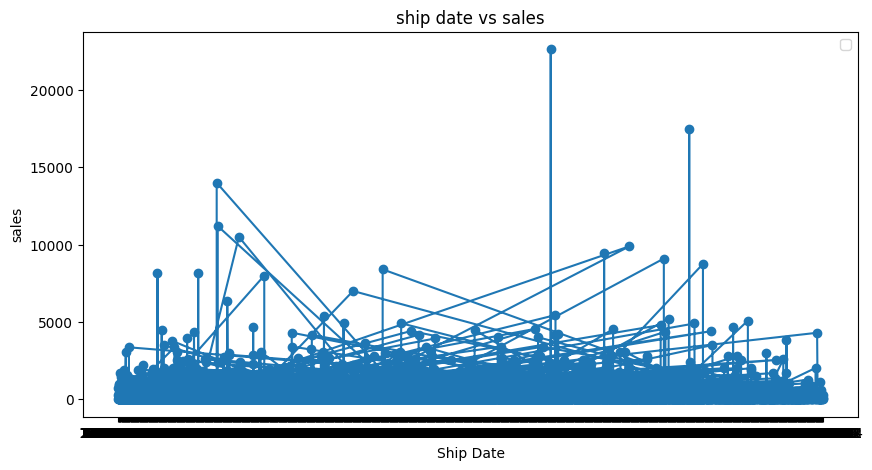

In [ ]:
plt.figure(figsize = (10,5))
plt.plot(df2["Ship Date"], df2["Sales"], marker = 'o')
plt.xlabel("Ship Date")
plt.ylabel("sales")
plt.title("ship date vs sales")
#plt.xticks(rotation=90)
plt.legend()
plt.show()

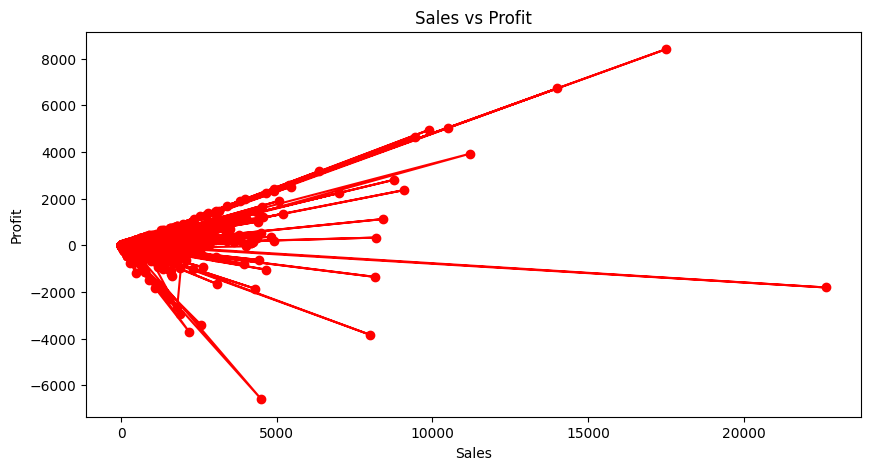

In [ ]:
#Sales vs profit line plot
plt.figure(figsize = (10,5))
plt.plot(df2["Sales"], df2["Profit"], color='red', marker = 'o')
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.title("Sales vs Profit")
plt.show()

**7.** Plot a Bar Chart for categorical vs numerical data.

In [ ]:
df.columns

Index(['Country/Region', 'Confirmed', 'Deaths', 'Recovered', 'Active',
       'New cases', 'New deaths', 'New recovered', 'Deaths / 100 Cases',
       'Recovered', 'Deaths_1', 'Confirmed last week', '1 week change',
       '1 week % increase', 'WHO Region'],
      dtype='object')

In [ ]:
df.head()

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered,Deaths_1,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa


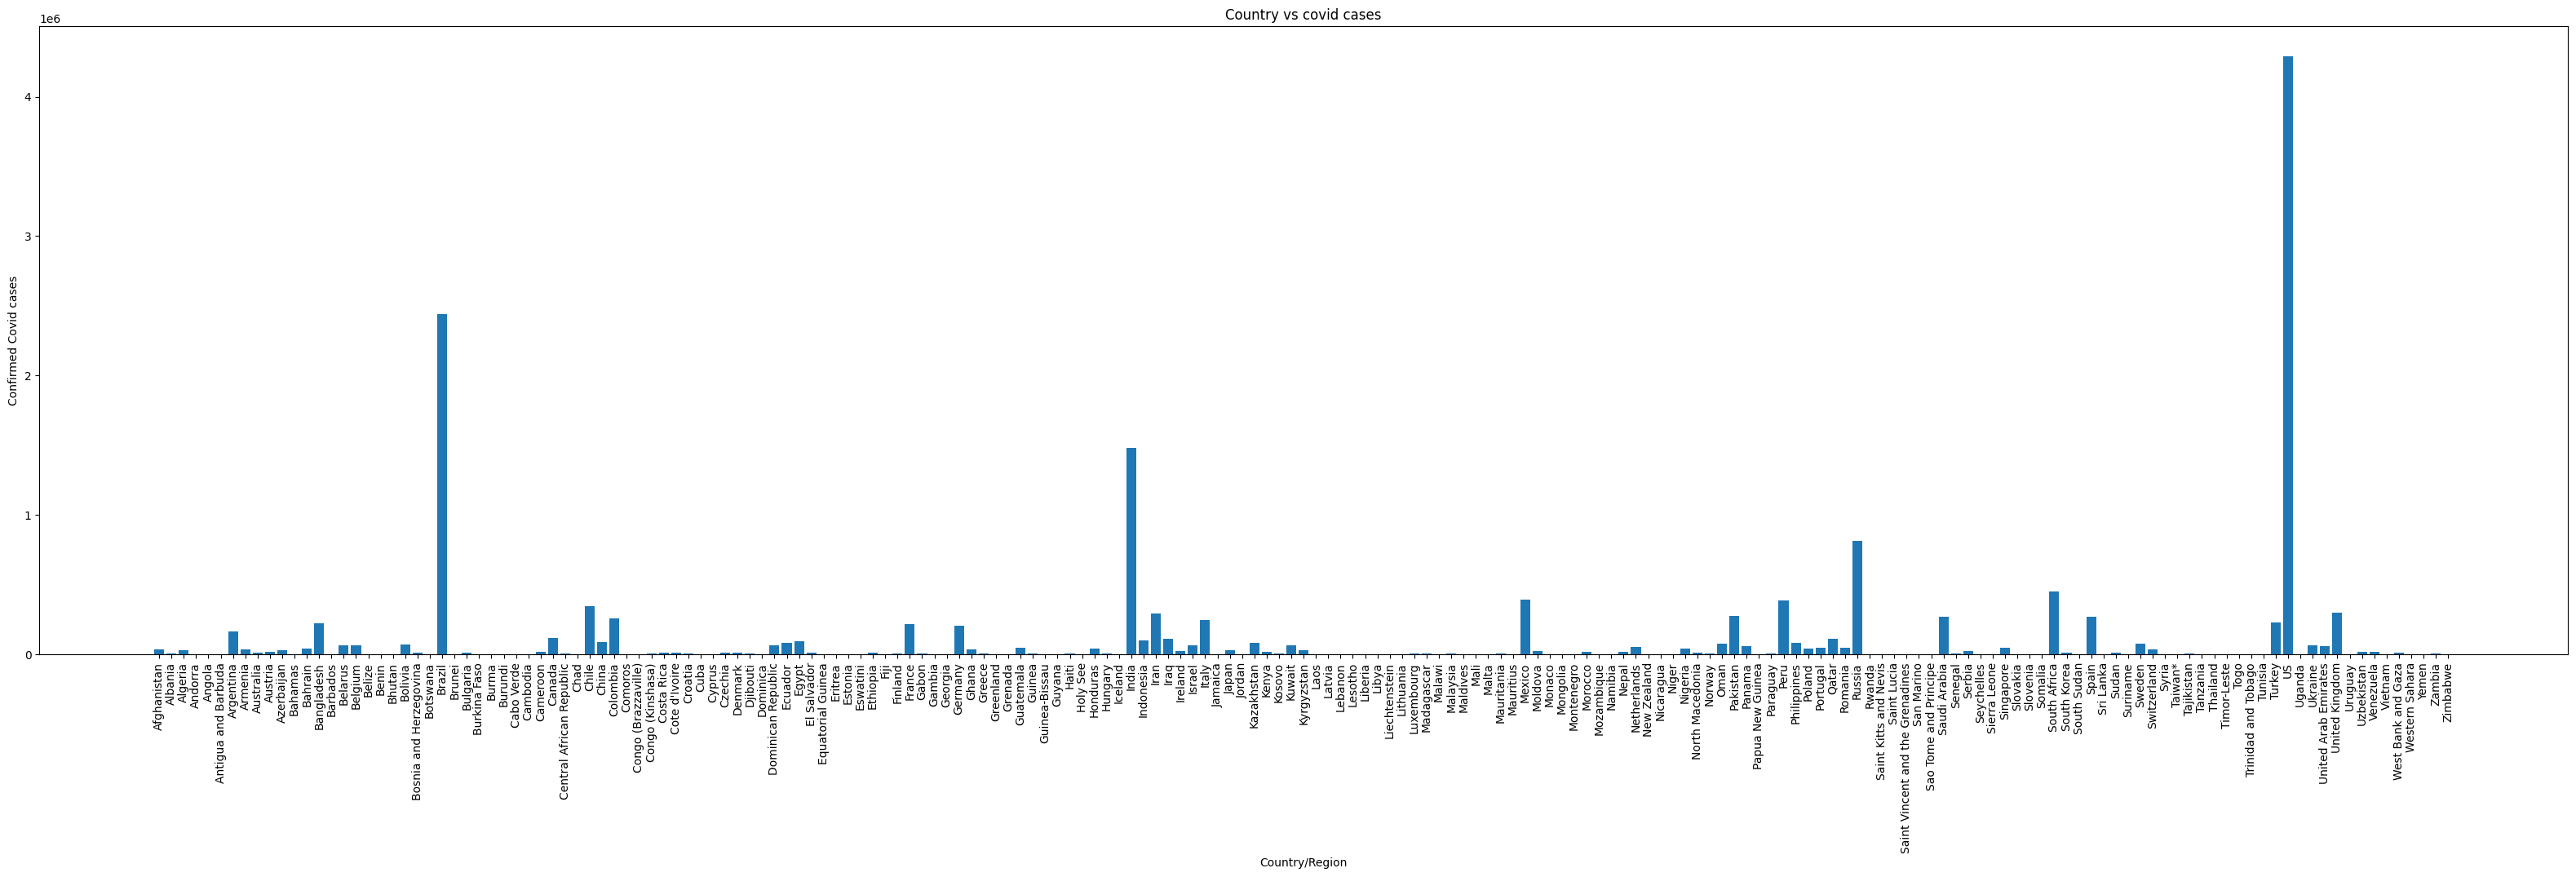

In [ ]:
plt.figure(figsize = (40,10))
plt.bar(df["Country/Region"], df["Confirmed"])
#sns.barplot(data = df, x = "Country/Region",y = "Confirmed")
plt.xlabel("Country/Region")
plt.ylabel("Confirmed Covid cases")
plt.title("Country vs covid cases")
plt.xticks(rotation=90)
plt.show()

**8.** Create a Scatter Plot to analyze relationships between two numerical variables.

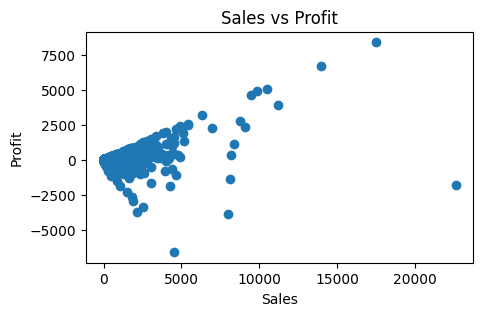

In [ ]:
plt.figure(figsize = (5,3))
plt.scatter(df2["Sales"], df2["Profit"])
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.title("Sales vs Profit")
plt.show()

**9.** Add a best-fit line (trend line) to the scatter plot.

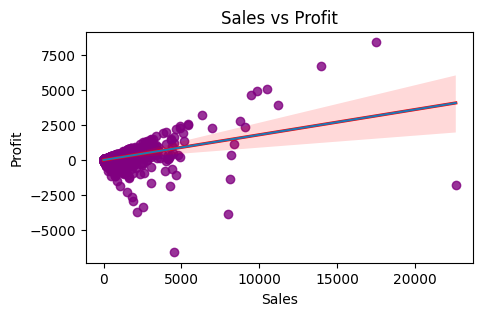

In [ ]:
plt.figure(figsize = (5,3))
#plt.scatter(df2["Sales"], df2["Profit"])
sns.regplot(data = df2, x="Sales", y="Profit", color='purple', line_kws={'color': 'red'})
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.title("Sales vs Profit")
#plt.plot(df2["Sales"], df2["Profit"])
plt.plot(np.unique(df2["Sales"]), np.poly1d(np.polyfit(df2["Sales"], df2["Profit"], 1))(np.unique(df2["Sales"])))
plt.show()

In [ ]:
x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 3, 5, 7, 11])

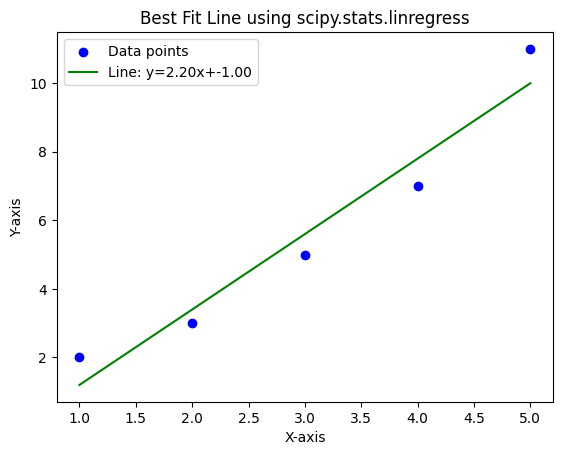

In [ ]:
# Perform linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
best_fit_line = slope * x + intercept

plt.scatter(x, y, color='blue', label='Data points')
plt.plot(x, best_fit_line, color='green', label=f'Line: y={slope:.2f}x+{intercept:.2f}')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Best Fit Line using scipy.stats.linregress')
plt.legend()
plt.show()

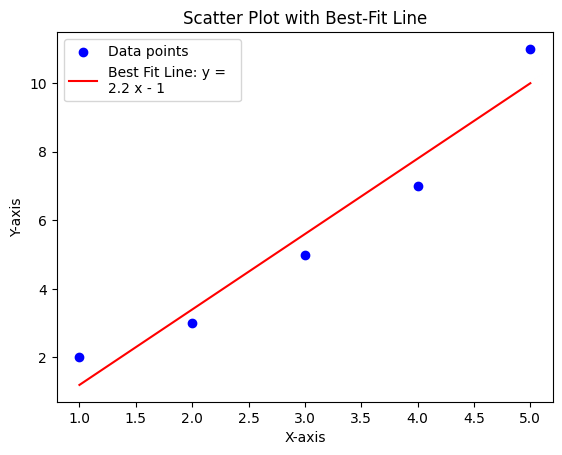

In [ ]:
# Fit a linear best-fit line (degree 1)
coefficients = np.polyfit(x, y, 1)
polynomial = np.poly1d(coefficients)

# Generate smooth line for plotting
x_line = np.linspace(x.min(), x.max(), 100)
y_line = polynomial(x_line)

plt.scatter(x, y, color='blue', label='Data points')
plt.plot(x_line, y_line, color='red', label=f'Best Fit Line: y = {polynomial}')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Scatter Plot with Best-Fit Line')
plt.legend()
plt.show()

**10.** Generate a Pie Chart to represent proportional data.

In [ ]:
df.head(2)

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered,Deaths_1,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe


In [ ]:
data = df.groupby("Country/Region")["Deaths"].sum().sort_values(ascending=False)
data

,Deaths
Country/Region,
US,148011
Brazil,87618
United Kingdom,45844
Mexico,44022
Italy,35112
...,...
Saint Lucia,0
Papua New Guinea,0
Saint Vincent and the Grenadines,0


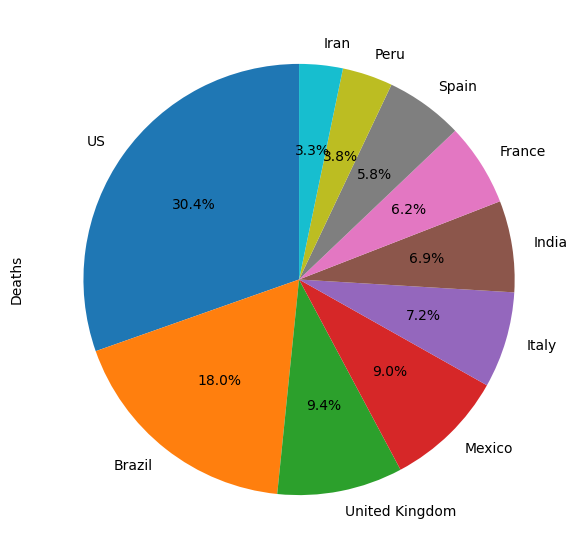

In [ ]:
newdata = data.head(10)
plt.figure(figsize = (7,7))
newdata.plot(kind="pie", autopct='%1.1f%%', startangle=90)
plt.show()

## Statistical Measures

In [ ]:
df.head()

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered,Deaths_1,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa


**11.** Compute the mean, median, and mode.

In [ ]:
mean = df["Deaths"].mean()
median = df["Deaths"].median()
mode = df["Country/Region"].mode()
print("Mean :- ", mean)
print("Median :- ", median)
print("Mode :- ", mode[0])

Mean :-  3497.51871657754
Median :-  108.0
Mode :-  Afghanistan


**12.** Calculate minimum, maximum, and range.

In [ ]:
max = df["Deaths"].max()
min = df["Deaths"].min()
range = max - min
print("Maximum :- ", max)
print("Minimum :- ", min)
print("Range :- ", range)

Maximum :-  148011
Minimum :-  0
Range :-  148011


**13.** Find the variance and standard deviation.

In [ ]:
var = df["Deaths"].var()
std = df["Deaths"].std()
print("Variance :- ", var)
print("Standard Deviation :- ", std)

Variance :-  198810069.99292737
Standard Deviation :-  14100.002482018483


**14.** Compute the quartiles (Q1, Q2, Q3).

In [ ]:
q1 = df["Deaths"].quantile(0.25)
q2 = df["Deaths"].quantile(0.50)
q3 = df["Deaths"].quantile(0.75)
print("Q1 :- ", q1)
print("Q2 :- ", q2)
print("Q3 :- ", q3)

Q1 :-  18.5
Q2 :-  108.0
Q3 :-  734.0


**15.** Calculate the Interquartile Range (IQR).

In [ ]:
iqr = q3 - q1
print("IQR :- ", iqr)

IQR :-  715.5


**16.** Identify outliers using the IQR method.

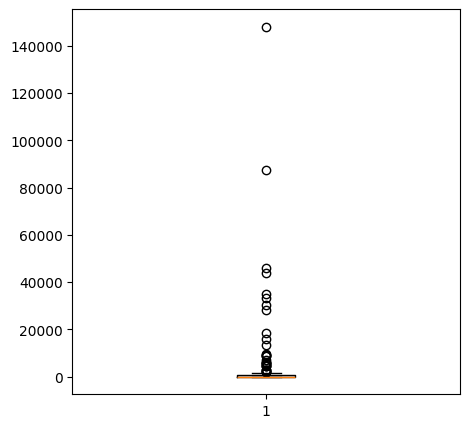

In [ ]:
plt.figure(figsize = (5,5))
plt.boxplot(df["Deaths"])
plt.show()

In [ ]:
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
print("Lower Quartile :- ", lower)
print("Upper Quartile :- ", upper)

Lower Quartile :-  -1054.75
Upper Quartile :-  1807.25


In [ ]:
outliers = df[(df["Deaths"] < lower) | (df["Deaths"] > upper)]
print("Outliers :- ", outliers.shape[0])
print(outliers.shape)

Outliers :-  33
(33, 15)


## Data Distribution Analysis

**17.** Plot a Histogram for at least two numerical attributes.

In [ ]:
df3 = pd.read_csv("/content/DailyDelhiClimateTest.csv", encoding = "latin1")
df3.head(2)

,date,meantemp,humidity,wind_speed,meanpressure
0,2017-01-01,15.913043,85.869565,2.743478,59.000000
1,2017-01-02,18.500000,77.222222,2.894444,1018.277778


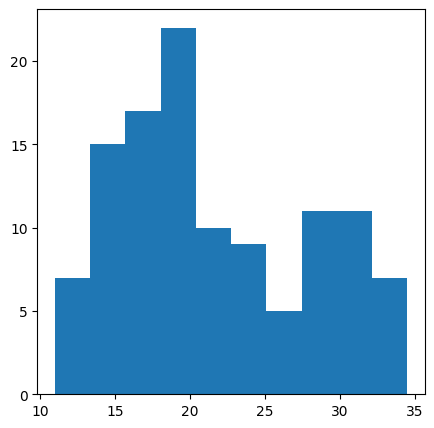

In [ ]:
plt.figure(figsize = (5,5))
plt.hist(df3["meantemp"], bins = 10)
plt.show()

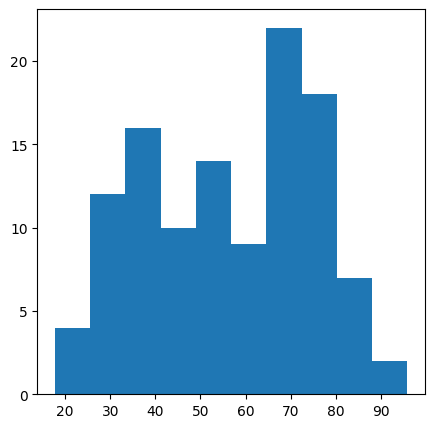

In [ ]:
plt.figure(figsize = (5,5))
plt.hist(df3["humidity"], bins = 10)
plt.show()

**18.** Draw a Box Plot to visualize data spread and outliers.

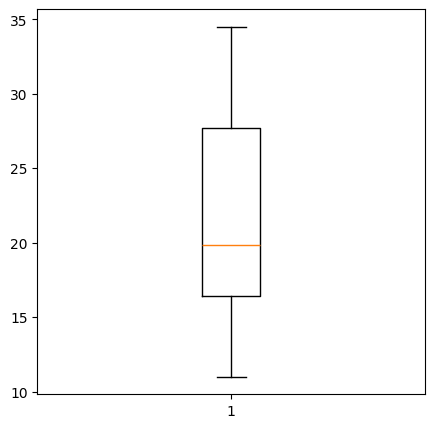

In [ ]:
plt.figure(figsize = (5,5))
plt.boxplot(df3["meantemp"])
plt.show()

**19.** Plot a Density Curve using histogram.

/tmp/ipython-input-3186143116.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df3["meantemp"], kde = True)


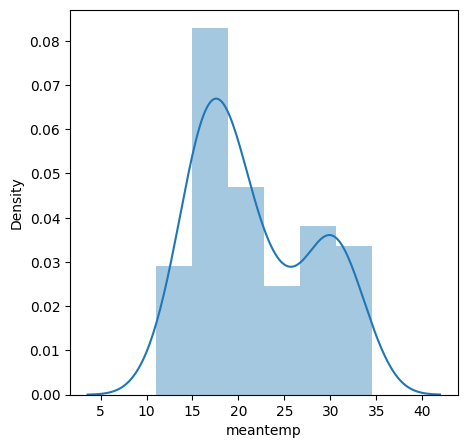

In [ ]:
plt.figure(figsize = (5,5))
sns.distplot(df3["meantemp"], kde = True)
plt.show()

**20.** Analyze whether the data follows normal distribution.

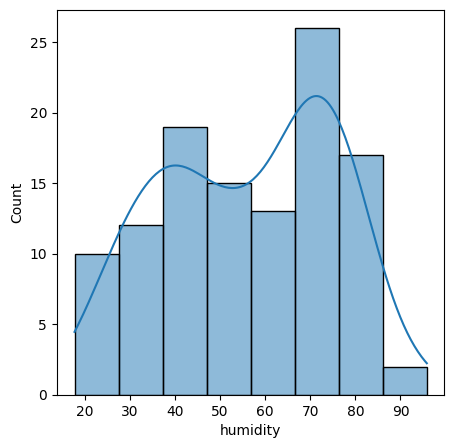

In [ ]:
plt.figure(figsize = (5,5))
sns.histplot(df3["humidity"], kde = True)
plt.show()

Yes, It is normally distributed

**21.** Explain the skewness of the distribution using graphs.

Ans.]  Skewness is zero ans it is normal distributed     
Also data is Bimodal

## Comparative and Advanced Visualization

**22.** Plot multiple graphs in a single figure.

Text(0.5, 1.0, 'Histogram of meantemp')

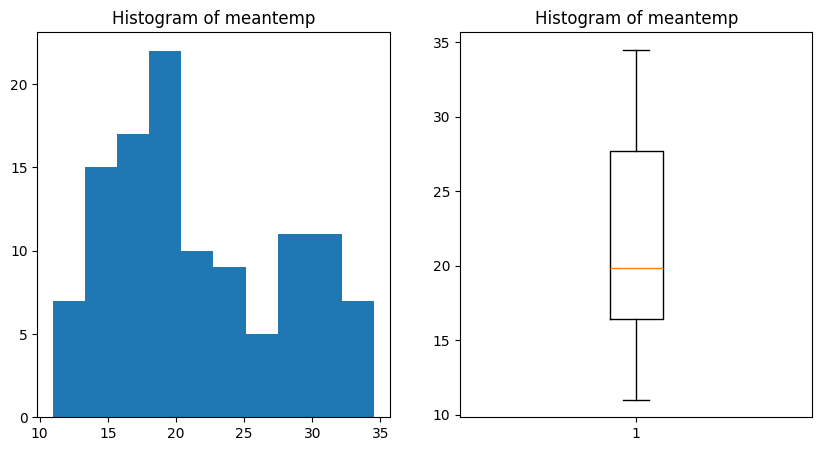

In [ ]:
# Plot multiple graphs in a single figure.
plt.figure(figsize = (10,5))
plt.subplot(1,2,1)
plt.hist(df3["meantemp"])
plt.title("Histogram of meantemp")

plt.subplot(1,2,2)
plt.boxplot(df3["meantemp"])
plt.title("Histogram of meantemp")

**23.** Compare two numerical attributes using a combined histogram.

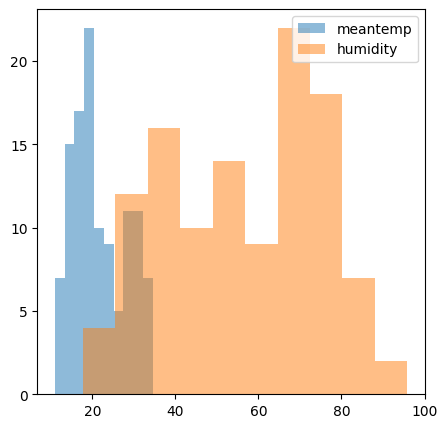

In [ ]:
plt.figure(figsize = (5,5))
plt.hist(df3["meantemp"], bins = 10, alpha = 0.5, label = "meantemp")
plt.hist(df3["humidity"], bins = 10, alpha = 0.5, label = "humidity")
plt.legend()
plt.show()

**24.** Create a subplot layout for different visualizations.

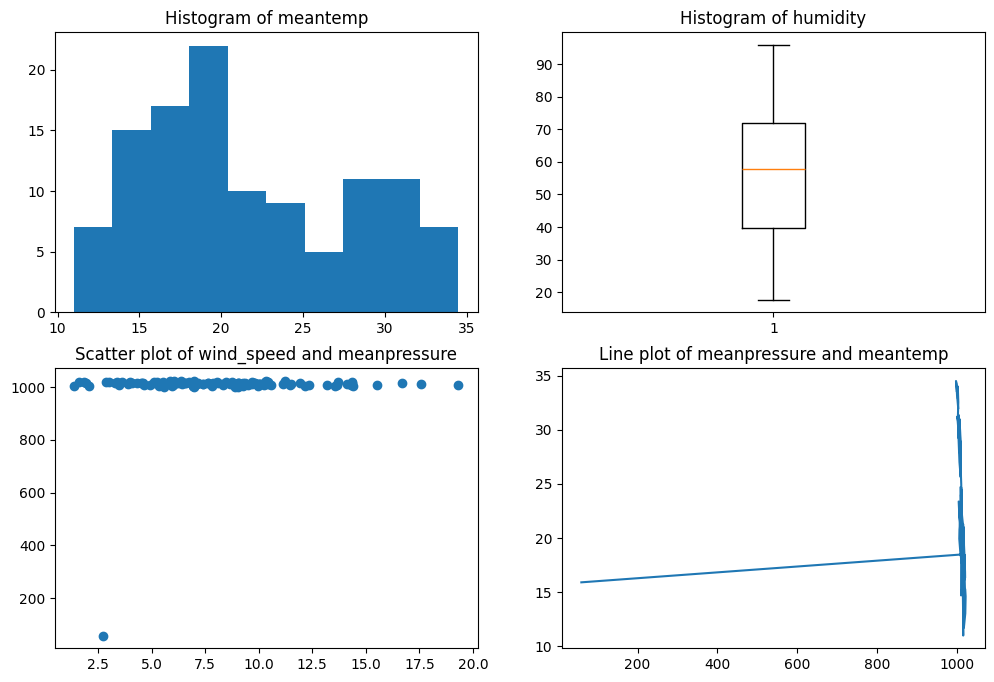

In [ ]:
plt.figure(figsize = (12,8))
plt.subplot(2,2,1)
plt.hist(df3["meantemp"])
plt.title("Histogram of meantemp")

plt.subplot(2,2,2)
plt.boxplot(df3["humidity"])
plt.title("Histogram of humidity")

plt.subplot(2,2,3)
plt.scatter(df3["wind_speed"], df3["meanpressure"])
plt.title("Scatter plot of wind_speed and meanpressure")

plt.subplot(2,2,4)
plt.plot(df3["meanpressure"], df3["meantemp"])
plt.title("Line plot of meanpressure and meantemp")
plt.show()

**25.** Visualize correlation using a scatter plot matrix.

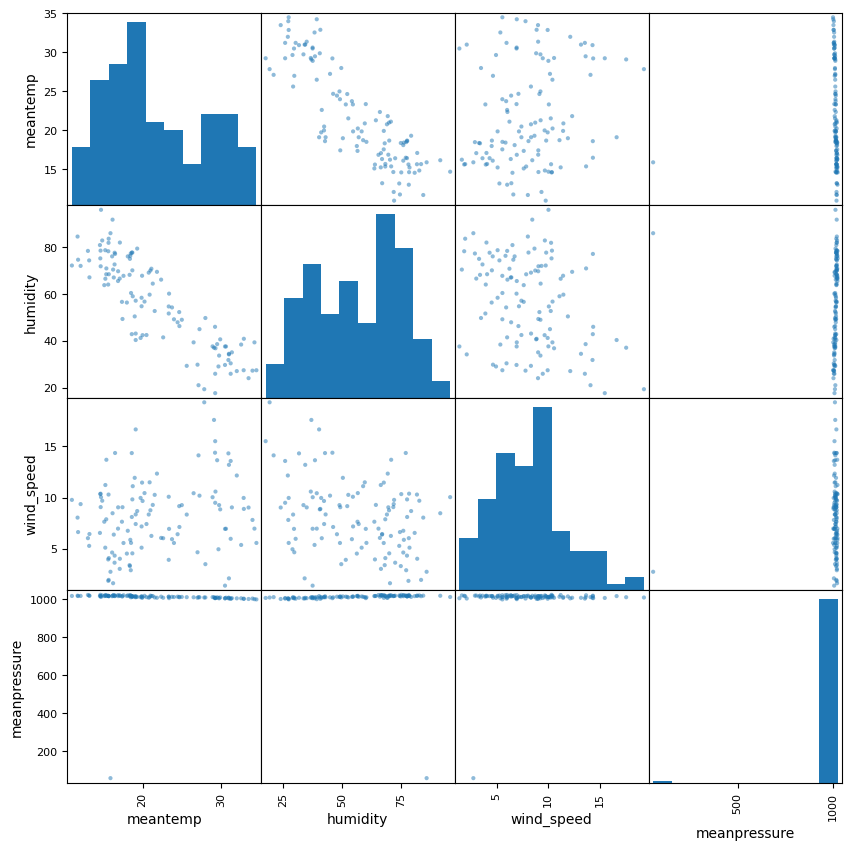

In [ ]:
from pandas.plotting import scatter_matrix
scatter_matrix(df3, figsize = (10,10))
plt.show()